In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df_history= pd.DataFrame({
    'Month': [
        "Month 1", "Month 2", "Month 3", "Month 4", "Month 5", "Month 6", 
        "Month 7", "Month 8", "Month 9", "Month 10", "Month 11", "Month 12"
    ],
    'Actual_Revenue': [
        100000, 102000, 98000, 105000, 110000, 108000, 
        115000, 112000, 120000, 118000, 125000, 122000
    ],
    'Actual_Cost': [
        60000, 61000, 59000, 63000, 65000, 64000, 
        68000, 67000, 72000, 71000, 75000, 74000
    ]
})

In [6]:
df_history

,Month,Actual_Revenue,Actual_Cost
0,Month 1,100000,60000
1,Month 2,102000,61000
2,Month 3,98000,59000
3,Month 4,105000,63000
4,Month 5,110000,65000
5,Month 6,108000,64000
6,Month 7,115000,68000
7,Month 8,112000,67000
8,Month 9,120000,72000
9,Month 10,118000,71000


In [7]:
print("🪵 經理人，這是你過去一年的【原始歷史流水帳】（這次保證統統到齊！）：")
print(df_history.to_string(index=False))

# 2. 計算過去的波動規律（標準差）
rev_std_pct = df_history['Actual_Revenue'].pct_change().std() # 營收月波動率
cost_std_pct = df_history['Actual_Cost'].pct_change().std()   # 成本月波動率

print(f"\n📈 透過原始記錄，Python 幫你算出了波動幅度：")
print(f"• 營收每個月上下飄移大約: {rev_std_pct*100:.1f}%")
print(f"• 成本每個月上下飄移大約: {cost_std_pct*100:.1f}%")

# 3. 預測明年第 1 個月（以今年底 Month 12 的 122,000 營收與 74,000 成本為基準目標，注入波動）
np.random.seed(42)
base_rev = 122000  
base_cost = 74000  
simulations = 1000

# 模擬明年第一個月的 1,000 種未來可能
sim_rev = base_rev * (1 + np.random.normal(0, rev_std_pct, simulations))
sim_cost = base_cost * (1 + np.random.normal(0, cost_std_pct, simulations))
sim_profit = sim_rev - sim_cost

print("\n🔮 根據歷史波動，模擬明年第一個月份的 1,000 次未來後：")
print(f"• 【最安全目標 P50】預期淨利為: {int(np.percentile(sim_profit, 50))} 元 (最可能發生的狀況)")
print(f"• 【悲觀防守線 P10】低谷淨利為: {int(np.percentile(sim_profit, 10))} 元 (只有 10% 的機率會比這個慘)")

🪵 經理人，這是你過去一年的【原始歷史流水帳】（這次保證統統到齊！）：
   Month  Actual_Revenue  Actual_Cost
 Month 1          100000        60000
 Month 2          102000        61000
 Month 3           98000        59000
 Month 4          105000        63000
 Month 5          110000        65000
 Month 6          108000        64000
 Month 7          115000        68000
 Month 8          112000        67000
 Month 9          120000        72000
Month 10          118000        71000
Month 11          125000        75000
Month 12          122000        74000

📈 透過原始記錄，Python 幫你算出了波動幅度：
• 營收每個月上下飄移大約: 4.5%
• 成本每個月上下飄移大約: 4.0%

🔮 根據歷史波動，模擬明年第一個月份的 1,000 次未來後：
• 【最安全目標 P50】預期淨利為: 47888 元 (最可能發生的狀況)
• 【悲觀防守線 P10】低谷淨利為: 39938 元 (只有 10% 的機率會比這個慘)


🚀 【頂級經理人情境對比預測系統】已啟動！



💬 Please enter multiple drift rates separated by commas (e.g., 0, 0.02, -0.01):  -0.02,0,0.03


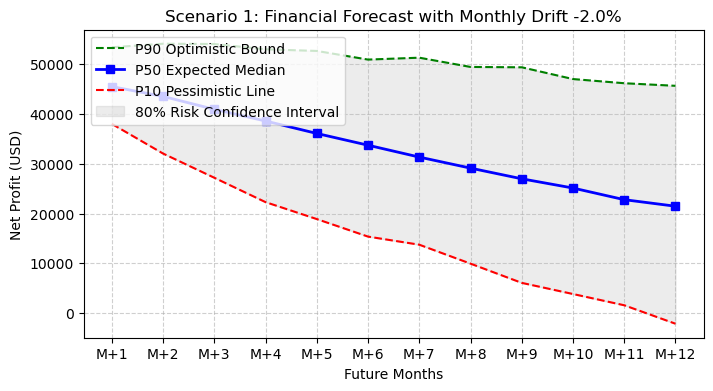

📊 【情境 1 摘要】M+12 預期: 21465 | 悲觀 P10: -2102


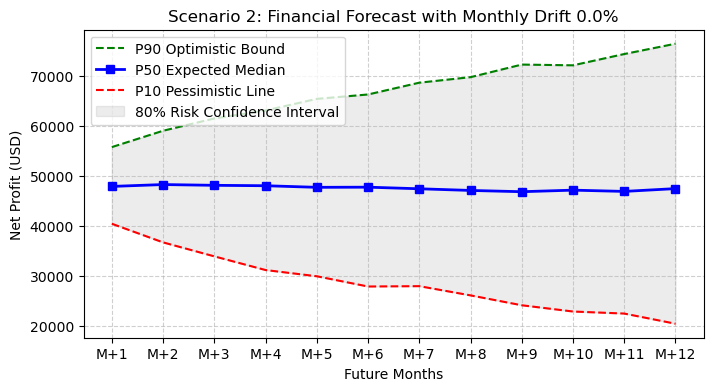

📊 【情境 2 摘要】M+12 預期: 47461 | 悲觀 P10: 20398


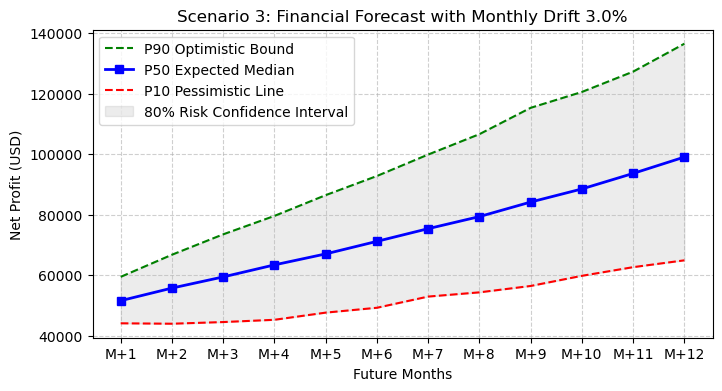

📊 【情境 3 摘要】M+12 預期: 99029 | 悲觀 P10: 64896

🔮 正在繪製第 n+1 張【終極多情境重疊對比大圖】...


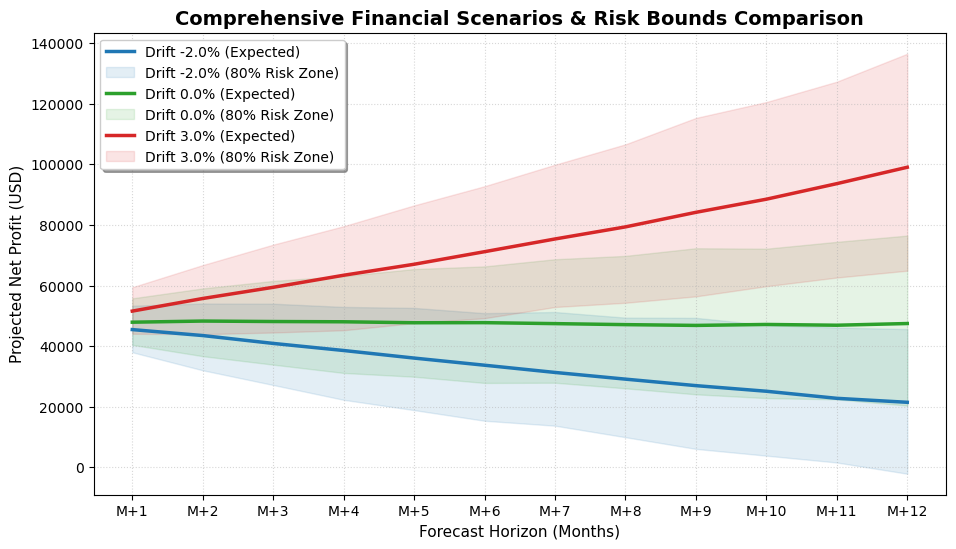


🏁 頂級對比大圖繪製完畢！這張圖可以直接放進對董事會報告的商業簡報中。


In [9]:
rev_std_pct = df_history['Actual_Revenue'].pct_change().std()
cost_std_pct = df_history['Actual_Cost'].pct_change().std()

print("🚀 【頂級經理人情境對比預測系統】已啟動！")

# 2. 取得經理人逗號分隔輸入
user_input = input("\n💬 Please enter multiple drift rates separated by commas (e.g., 0, 0.02, -0.01): ")

if user_input.strip() == "":
    print("👋 No input detected. System exiting.")
else:
    try:
        drift_list = [float(x.strip()) for x in user_input.split(',') if x.strip() != ""]
        months_future = [f"M+{i}" for i in range(1, 13)]
        
        # 建立一個容器，用來裝最後一張大圖要用的所有情境數據
        all_scenarios_data = []
        
        # 3. 循環模擬每一種情境，並繪製前 n 張獨立圖
        for idx, target_drift in enumerate(drift_list, 1):
            np.random.seed(42) # 固定隨機種子
            simulations = 1000
            rev_sims = np.zeros((simulations, 12))
            cost_sims = np.zeros((simulations, 12))
            
            for i in range(simulations):
                cur_rev = 122000   
                cur_cost = 74000   
                for m in range(12):
                    cur_rev = cur_rev * (1 + np.random.normal(target_drift, rev_std_pct))
                    cur_cost = cur_cost * (1 + np.random.normal(0, cost_std_pct))
                    rev_sims[i, m] = cur_rev
                    cost_sims[i, m] = cur_cost
                    
            profit_sims = rev_sims - cost_sims
            p10 = np.percentile(profit_sims, 10, axis=0)
            p50 = np.percentile(profit_sims, 50, axis=0)
            p90 = np.percentile(profit_sims, 90, axis=0)
            
            # 將數據存入容器，留給大圖用
            all_scenarios_data.append({
                'drift': target_drift,
                'p10': p10,
                'p50': p50,
                'p90': p90
            })
            
            # 繪製前 n 張獨立詳細圖（標題與圖例改為全英文）
            plt.figure(figsize=(8, 4))
            plt.plot(months_future, p90, label='P90 Optimistic Bound', color='green', linestyle='--')
            plt.plot(months_future, p50, label='P50 Expected Median', color='blue', marker='s', linewidth=2)
            plt.plot(months_future, p10, label='P10 Pessimistic Line', color='red', linestyle='--')
            plt.fill_between(months_future, p10, p90, color='gray', alpha=0.15, label='80% Risk Confidence Interval')
            
            plt.title(f"Scenario {idx}: Financial Forecast with Monthly Drift {target_drift*100:.1f}%")
            plt.xlabel("Future Months")
            plt.ylabel("Net Profit (USD)")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(loc='upper left')
            plt.show()
            
            print(f"📊 【情境 {idx} 摘要】M+12 預期: {int(p50[-1])} | 悲觀 P10: {int(p10[-1])}")
            
        # =========================================================================
        # 🌟 核心亮點：追加繪製第 n+1 張「終極多情境重疊陰影大圖」
        # =========================================================================
        print("\n🔮 正在繪製第 n+1 張【終極多情境重疊對比大圖】...")
        plt.figure(figsize=(11, 6))
        
        # 預設一組高雅的莫蘭迪對比配色
        colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
        
        for idx, sc in enumerate(all_scenarios_data):
            color = colors[idx % len(colors)]
            label_text = f"Drift {sc['drift']*100:.1f}%"
            
            # 1. 畫 P50 折線：純線條，不帶任何 Marker 標記
            plt.plot(months_future, sc['p50'], color=color, linewidth=2.5, label=f"{label_text} (Expected)")
            
            # 2. 畫 P10-P90 包夾區域：不畫 P10/P90 折線，純粹用半透明顏色上色
            plt.fill_between(months_future, sc['p10'], sc['p90'], color=color, alpha=0.12, 
                             label=f"{label_text} (80% Risk Zone)")
            
        plt.title("Comprehensive Financial Scenarios & Risk Bounds Comparison", fontsize=14, fontweight='bold')
        plt.xlabel("Forecast Horizon (Months)", fontsize=11)
        plt.ylabel("Projected Net Profit (USD)", fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.legend(loc='upper left', frameon=True, shadow=True)
        plt.show()
        
        print("\n🏁 頂級對比大圖繪製完畢！這張圖可以直接放進對董事會報告的商業簡報中。")
        
    except ValueError:
        print("❌ Input parsing error! Please ensure the format is like: 0, 0.02, -0.01")

🚀 【頂級經理人情境對比預測系統 4.0】已啟動！



💬 Please enter multiple drift rates separated by commas (e.g., 0, 0.02, -0.01):  -0.02,0,0.03



🔮 Rendering the final Comprehensive Business Scenario Comparison Chart...


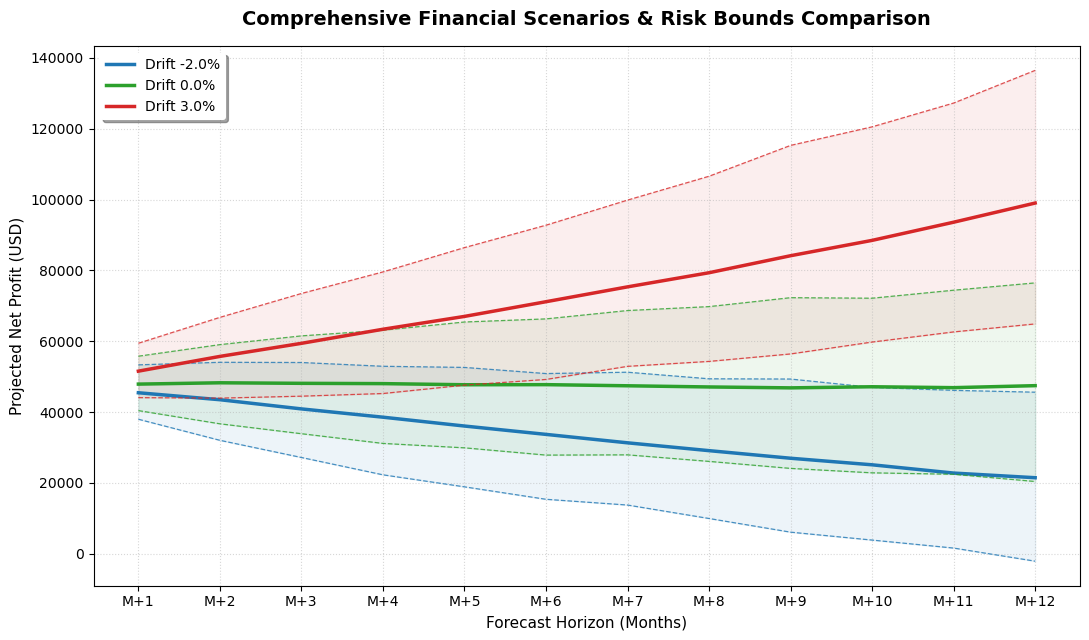


🏁 殿堂級對比大圖繪製完畢！邊界清晰、層次分明，任務 A 完美交卷。


In [10]:
rev_std_pct = df_history['Actual_Revenue'].pct_change().std()
cost_std_pct = df_history['Actual_Cost'].pct_change().std()

print("🚀 【頂級經理人情境對比預測系統 4.0】已啟動！")

# 2. 取得經理人逗號分隔輸入
user_input = input("\n💬 Please enter multiple drift rates separated by commas (e.g., 0, 0.02, -0.01): ")

if user_input.strip() == "":
    print("👋 No input detected. System exiting.")
else:
    try:
        drift_list = [float(x.strip()) for x in user_input.split(',') if x.strip() != ""]
        months_future = [f"M+{i}" for i in range(1, 13)]
        all_scenarios_data = []
        
        # 3. 循環模擬每一種情境，並建立數據庫
        for idx, target_drift in enumerate(drift_list, 1):
            np.random.seed(42) # 固定隨機種子
            simulations = 1000
            rev_sims = np.zeros((simulations, 12))
            cost_sims = np.zeros((simulations, 12))
            
            for i in range(simulations):
                cur_rev = 122000   
                cur_cost = 74000   
                for m in range(12):
                    cur_rev = cur_rev * (1 + np.random.normal(target_drift, rev_std_pct))
                    cur_cost = cur_cost * (1 + np.random.normal(0, cost_std_pct))
                    rev_sims[i, m] = cur_rev
                    cost_sims[i, m] = cur_cost
                    
            profit_sims = rev_sims - cost_sims
            p10 = np.percentile(profit_sims, 10, axis=0)
            p50 = np.percentile(profit_sims, 50, axis=0)
            p90 = np.percentile(profit_sims, 90, axis=0)
            
            all_scenarios_data.append({
                'drift': target_drift,
                'p10': p10,
                'p50': p50,
                'p90': p90
            })
            
        # =========================================================================
        # 🌟 核心升級：繪製完美對齊高手思維的【終極重疊對比大圖】
        # =========================================================================
        print("\n🔮 Rendering the final Comprehensive Business Scenario Comparison Chart...")
        plt.figure(figsize=(11, 6.5))
        
        # 精選高階簡報配色（深藍、翠綠、磚紅、紫羅蘭、深灰）
        colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#555555']
        
        for idx, sc in enumerate(all_scenarios_data):
            color = colors[idx % len(colors)]
            label_text = f"Drift {sc['drift']*100:.1f}%"
            
            # 1. 畫 P50 主線：粗實線，不帶標記
            plt.plot(months_future, sc['p50'], color=color, linewidth=2.5, label=f"{label_text}")
            
            # 2. ⚡【高手修正】畫 P90 與 P10 邊界線：細虛線、無標記、與主線同色
            plt.plot(months_future, sc['p90'], color=color, linestyle='--', linewidth=0.9, alpha=0.8)
            plt.plot(months_future, sc['p10'], color=color, linestyle='--', linewidth=0.9, alpha=0.8)
            
            # 3. 畫 P10-P90 包夾區域：降低 alpha 值（0.08），確保重疊時依然保持高通透度
            plt.fill_between(months_future, sc['p10'], sc['p90'], color=color, alpha=0.08)
            
        plt.title("Comprehensive Financial Scenarios & Risk Bounds Comparison", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel("Forecast Horizon (Months)", fontsize=11)
        plt.ylabel("Projected Net Profit (USD)", fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.5)
        
        # 建立簡潔的圖例說明（只顯示情境名稱，避免圖例冗長）
        plt.legend(loc='upper left', frameon=True, shadow=True, facecolor='white', edgecolor='none')
        plt.tight_layout()
        plt.show()
        
        print("\n🏁 殿堂級對比大圖繪製完畢！邊界清晰、層次分明，任務 A 完美交卷。")
        
    except ValueError:
        print("❌ Input parsing error! Please ensure the format is like: 0, 0.02, -0.01")